# <b>[공모전] RNN 시계열 날씨 예측

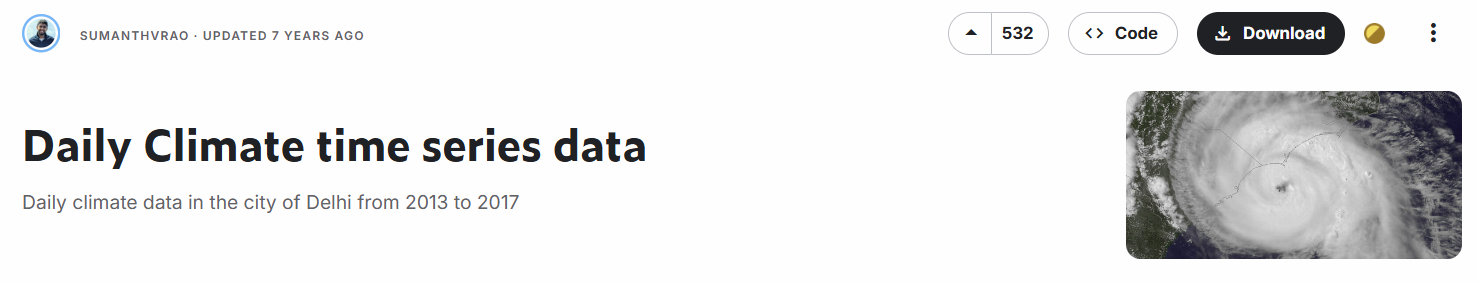
* https://www.kaggle.com/datasets/sumanthvrao/daily-climate-time-series-data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split                     

#----------------------------------------------------------------------------------  DL모델 
from tensorflow.keras import Sequential
from tensorflow.keras.layers import LSTM, Dropout, GRU, Bidirectional
from tensorflow.keras.layers import Flatten, Dense, Rescaling
from tensorflow.keras.initializers import GlorotNormal    #Xavier

import math
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler


#----------------------------------------------------------------------------------  랜덤시드 고정 
import tensorflow as tf
tf.random.set_seed(54546)
np.random.seed(54546)

#----------------------------------------------------------------------------------  조기종료
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
    

import warnings
warnings.filterwarnings('ignore')

sns.set()

#-------------------- 차트 관련 속성 (한글처리, 그리드) -----------
plt.rcParams['font.family']= 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

#-------------------- 주피터 , 출력결과 넓이 늘리기 ---------------
# from IPython.core.display import display, HTML
from IPython.display import display, HTML
display(HTML("<style>.container{width:100% !important;}</style>"))
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
pd.set_option('max_colwidth', None)

# <b>Data Load

In [13]:
test = pd.read_csv(r"C:\IT\workspace_ptyhon\dl\Daily Climate time\DailyDelhiClimateTest.csv")
dataset= pd.read_csv(r"C:\IT\workspace_ptyhon\dl\Daily Climate time\DailyDelhiClimateTrain.csv")

In [14]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


# <b>train_test_split

train(1402일) - train(80%), val(20%) <br>
test(60일)

In [15]:
test = dataset[-60:]
len(dataset), len(test)

(1462, 60)

In [16]:
train, val = train_test_split(dataset[:-60], test_size = 0.2, shuffle = False)
len(train), len(val)

(1121, 281)

# <b>EDA

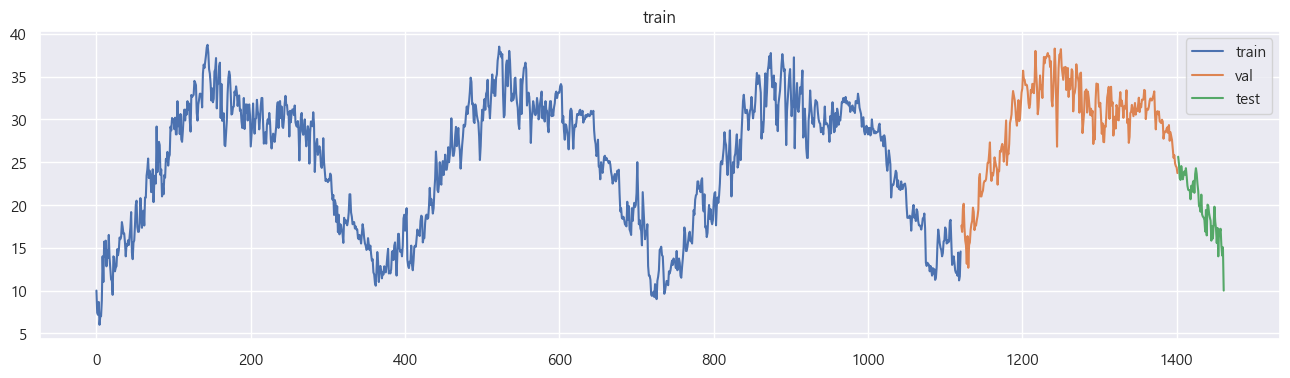

In [17]:
dataset['meantemp'][:len(train)].plot(figsize=(16,4),legend=True) # 평균온도컬럼의 처음부터 train길이까지
dataset["meantemp"][len(train) : len(train)+len(val)].plot(figsize=(16,4),legend=True) # train ~ train+val까지
dataset["meantemp"][len(train)+len(val) : ].plot(figsize=(16,4),legend=True) # train+val ~ 끝까지

plt.legend(['train','val','test']) # 범례설정
plt.title('train')
plt.show()

```python
[:len(train)]
[len(train):len(train)+len(val)]
[len(train)+len(val):]
시계열 train/val/test자르는 기본패턴

# <b>전처리 & 가공

In [18]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1462 entries, 0 to 1461
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          1462 non-null   object 
 1   meantemp      1462 non-null   float64
 2   humidity      1462 non-null   float64
 3   wind_speed    1462 non-null   float64
 4   meanpressure  1462 non-null   float64
dtypes: float64(4), object(1)
memory usage: 57.2+ KB


## <b>파생피쳐

## <b>스케일링

## <b>윈도우 슬라이딩

## <font color=red><b>input_shape : 3D
* samples : 데이터 갯수
* timestep : window_size
* features : 변수갯수 == df['cnt']

# <b>모델 & 평가

# <b>답안지 제출